In [1]:
#Basic Setup
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "p", "theta", "beta","chi2pid", "vz", "sector", "phi"]
kinematics =["Mx_eKX", "Q2", "W", "y"]

for kin in kinematics:
    cols.append(kin)

#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
df2 =df.copy()
#creates a list of matching events (excludes events that failed matching)
#matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/"  #path directory for saving pngs :)
#matched=baseline

#matched = matched[(matched["nphe_htcc"]!=-9999)&(matched["nphe_htcc"]!=0)]
#print("ftof_path_1A:  ", matched["nphe_htcc"].describe())
#print("\nQuick eyeball:")
#print(f"  ftof_time_1A range: [{matched['nphe_htcc'].min():.2f}, {matched['nphe_htcc'].max():.2f}]")

allPlots =[]



In [2]:
baseline=df[
(df["Q2"]>2)&
(df["W"]>2)&
(df["Mx_eKX"]>1.6)&
((df["y"]>0)&(df["y"]<0.75))
]
df=baseline


In [3]:
ranges=[
[-2212, 2212], #pid
[0.5, 5],    #p
[4, 44], #theta
[0, 1],  #beta  
[-10, 10], #chi2pid
[-10,2], #Vz (Real data has hard cut a 0.6
[0, 6], #sector
[0,360],  #Phi
[0,5], #Mx
[0,10], #Q2
[0,5], #W
[0,1] #y
]    

parts = [321, 211, 2212]
colors= ["Red", "Blue"]
labels=["kinimatic Cut", "No Cut"]

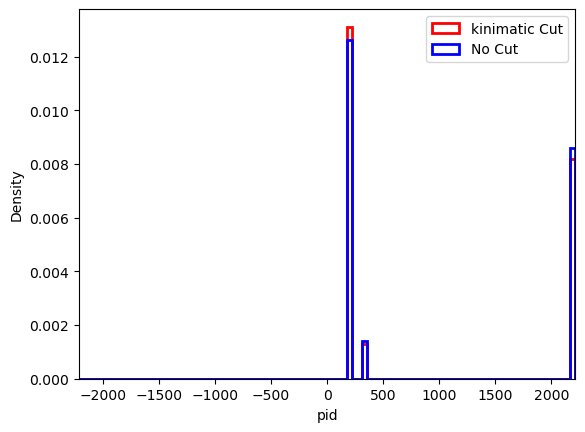

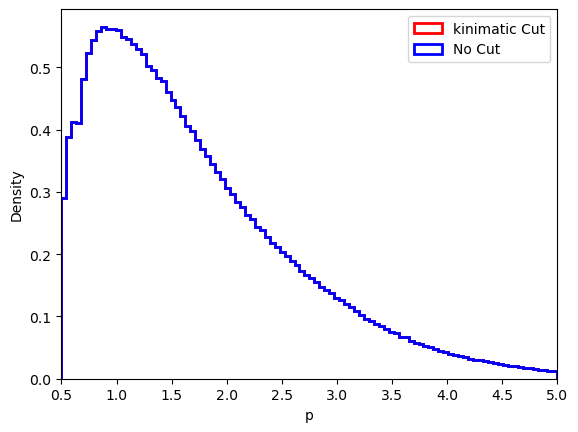

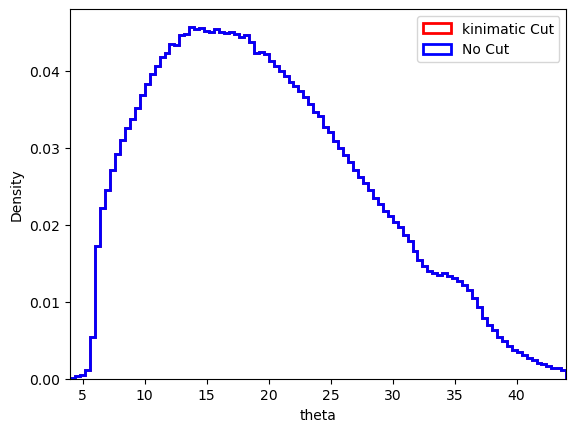

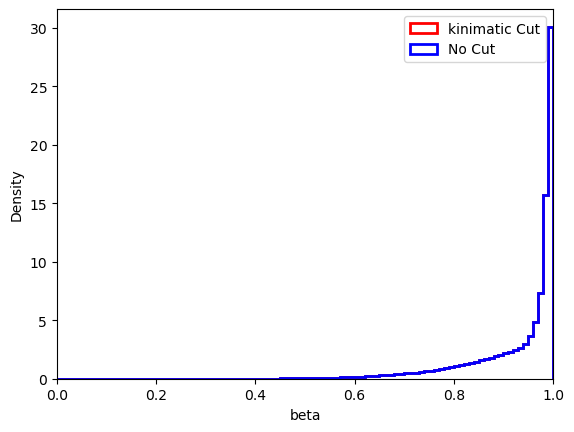

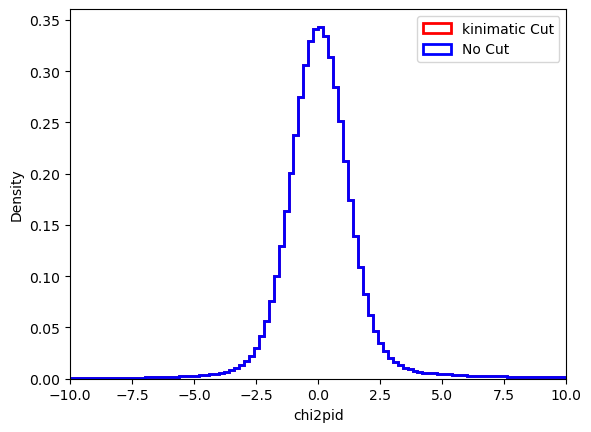

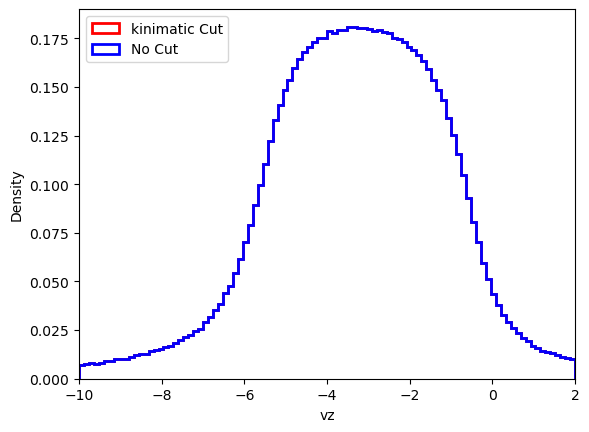

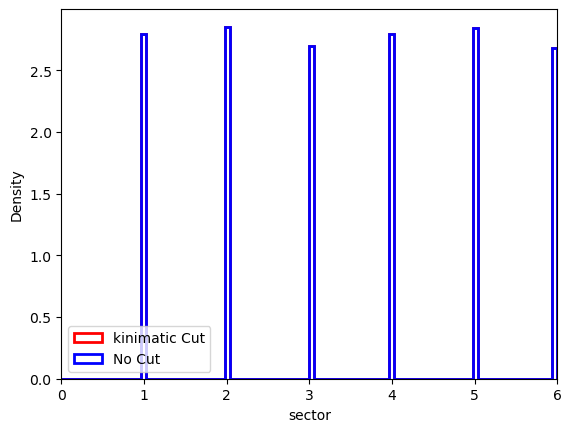

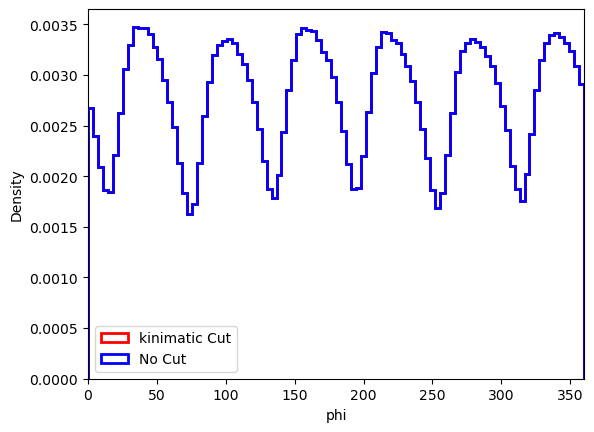

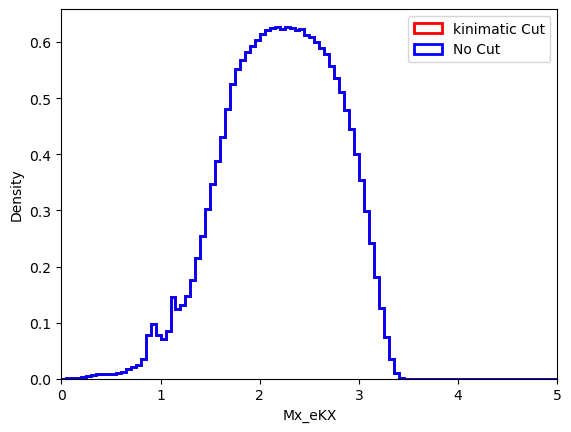

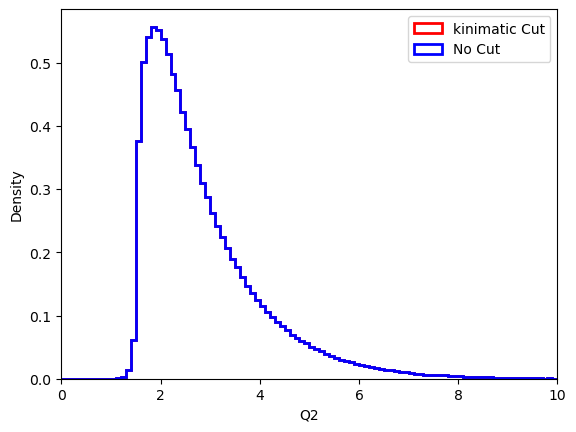

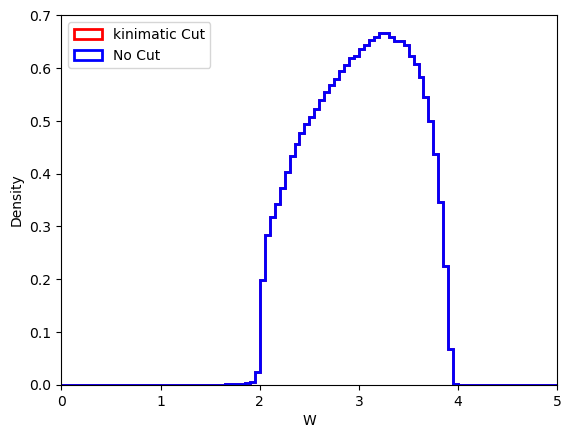

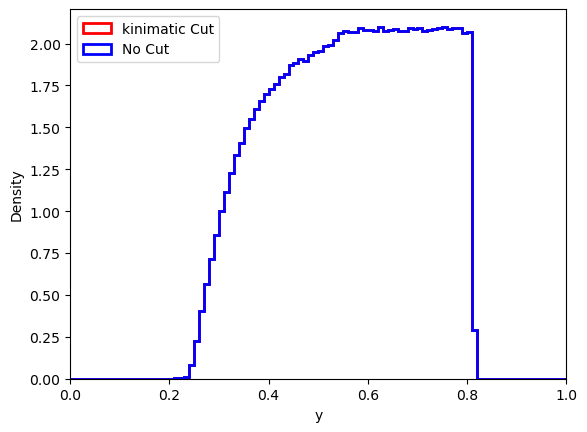

In [4]:
cnt=0
for varbs in cols:
    dfs=[df,df2]
    fig, ax = plt.subplots()
    for i, df in enumerate(dfs):
            ax.hist(
                dfs[i][varbs],
                bins=100,
                range=(ranges[cnt][0], ranges[cnt][1]),
                histtype='step',
                color=colors[i],
                density=True,
                linewidth=2,
                label=labels[i]
            )
    ax.set_xlim(ranges[cnt][0], ranges[cnt][1])
    ax.set_xlabel(varbs)
    ax.set_ylabel("Density")
    ax.legend()
    fig.savefig(direct+varbs+"CompareKinCuts.png", dpi=150)
    allPlots.append(fig)
    cnt=cnt+1
    plt.show()

In [5]:
with PdfPages(direct + "KinematicCuts.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)